## Experiment No: 8
## Experiment Title: K-Means Clustering - Finding the Optimal Number of Clusters using Elbow and Silhouette Method

**Name:** Himanshu Jadhav  
**Roll Number:** TE-33

### Step 1: Import Required Libraries

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


sns.set_theme(style="whitegrid")
np.random.seed(33)

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


### Step 2: Load the Dataset - Handwritten Digits
This experiment uses the **Optical Recognition of Handwritten Digits** dataset: 1,797 real 8x8 pixel grayscale images of handwritten digits (0-9), each flattened into a 64-feature vector (one feature per pixel intensity). Unlike simple 2-4 feature datasets, this gives K-Means a genuinely high-dimensional space to cluster, and each cluster centroid can be visualized back as an actual digit image.

In [2]:
digits = load_digits()
x      = digits.data
y_true = digits.target

print("Shape of Digits Dataset : ", x.shape)
print("Number of Classes       : ", len(np.unique(y_true)))

Shape of Digits Dataset :  (1797, 64)
Number of Classes       :  10


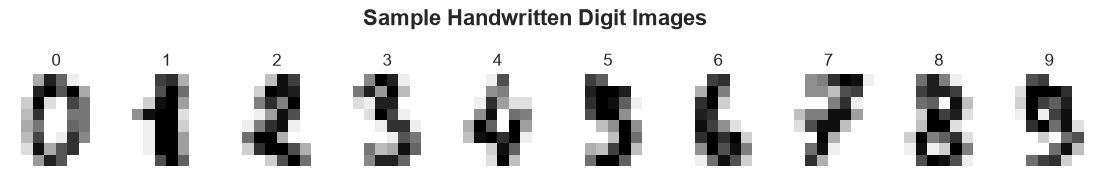

In [3]:
fig, axes = plt.subplots(1, 10, figsize=(14, 2))

for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(str(y_true[i]))
    ax.axis("off")
fig.suptitle("Sample Handwritten Digit Images", y=1.05, fontsize=16, fontweight='bold')
plt.show()

### Step 3: Prepare Features for Clustering
Pixel intensities are standardized to zero mean and unit variance so that no single pixel region dominates the Euclidean distance calculation used internally by K-Means.

In [5]:
scaler   = StandardScaler()
x_scaled = scaler.fit_transform(x)

print(f"Original Features Shape     : {x.shape}")
print(f"Scaled   Features Shape     : {x_scaled.shape}")

Original Features Shape     : (1797, 64)
Scaled   Features Shape     : (1797, 64)


### Step 4: Elbow Method - Finding Optimal K using Within-Cluster Sum of Squares (WCSS)

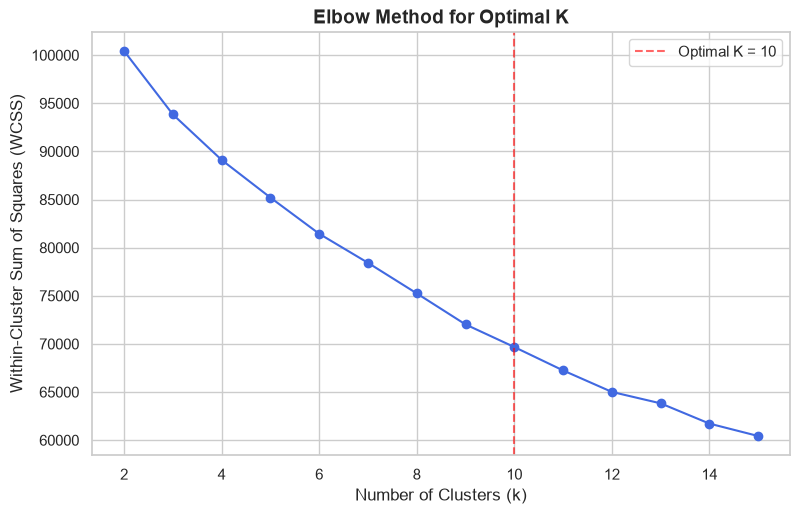

In [6]:
wcss    = []
k_range = range(2, 16)

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=33)
    km.fit(x_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(9, 5.5))
plt.plot(list(k_range), wcss, marker='o', color='royalblue')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.axvline(x=10, color='red', linestyle='--', label='Optimal K = 10', alpha=0.6)
plt.legend()
plt.show()

### Step 5: Silhouette Method - Finding Optimal K using Silhouette Score

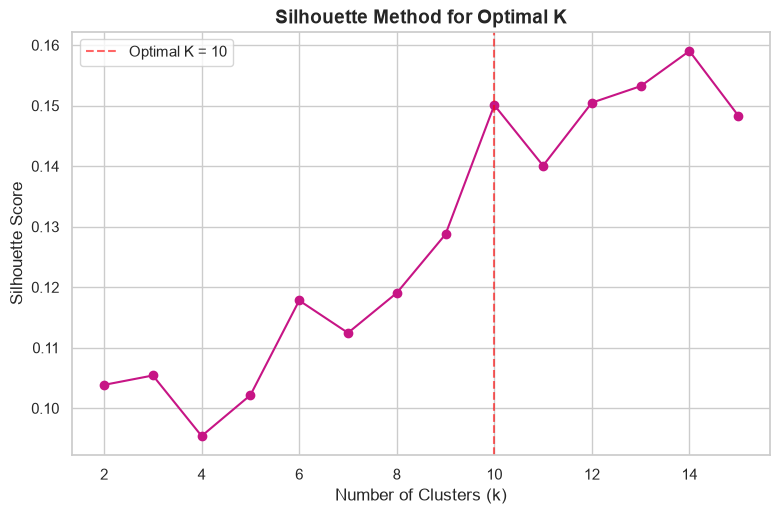

Optimal K based on Silhouette Score: 14 with score 0.1590


In [7]:
sil_scores = []

for k in k_range:
    km        = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=33)
    labels    = km.fit_predict(x_scaled)
    sil_score = silhouette_score(x_scaled, labels)
    sil_scores.append(sil_score)

plt.figure(figsize=(9, 5.5))
plt.plot(list(k_range), sil_scores, marker='o', color='mediumvioletred')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Method for Optimal K', fontsize=14, fontweight='bold')
plt.axvline(x=10, color='red', linestyle='--', label='Optimal K = 10', alpha=0.6)
plt.legend()
plt.show()

best_sil_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Optimal K based on Silhouette Score: {best_sil_k} with score {max(sil_scores):.4f}")

### Step 6: Train Final K-Means Model
Since the digits dataset has a **known ground truth** of 10 digit classes (0-9), K=10 is chosen as the optimal number of clusters for the final model, even though the silhouette curve (which has no knowledge of the true labels) may peak elsewhere due to overlapping pixel-space structure between visually similar digits (e.g., 4 vs 9, or 3 vs 8).

In [8]:
optimal_k      = 10
kmeans_final   = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=33)
cluster_labels = kmeans_final.fit_predict(x_scaled)

print("Final K-Means Model Trained Successfully.")
print(f"Number of Clusters     : {optimal_k}")
print(f"Final Silhouette Score : {silhouette_score(x_scaled, cluster_labels):.4f}")

Final K-Means Model Trained Successfully.
Number of Clusters     : 10
Final Silhouette Score : 0.1501


### Step 7: Visualize Clusters using PCA (2D Projection)

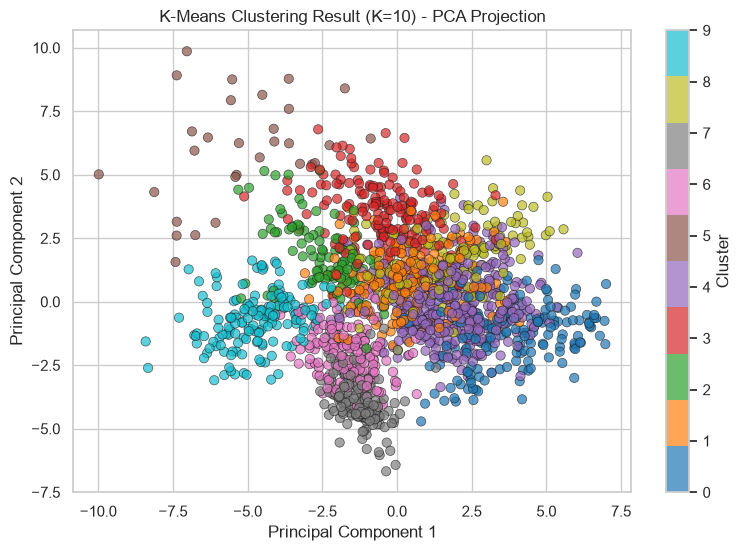

Variance explained by 2 components: 21.59%
(Some cluster overlap in 2D is expected -- the true structure lives in 64 dimensions.)


In [9]:
pca   = PCA(n_components=2, random_state=33)
x_pca = pca.fit_transform(x_scaled)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(x_pca[:, 0], x_pca[:, 1], c=cluster_labels, cmap='tab10', s=45, alpha=0.7, edgecolor='k', linewidth=0.5)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.title(f"K-Means Clustering Result (K={optimal_k}) - PCA Projection")
plt.colorbar(scatter, label="Cluster")
plt.show()


print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")
print("(Some cluster overlap in 2D is expected -- the true structure lives in 64 dimensions.)")

### Step 8: Visualize Cluster Centroids as Digit Images
Because each feature corresponds to a pixel intensity, every cluster centroid can be reshaped back into an 8x8 image. This shows exactly what "average digit" each cluster has converged toward.

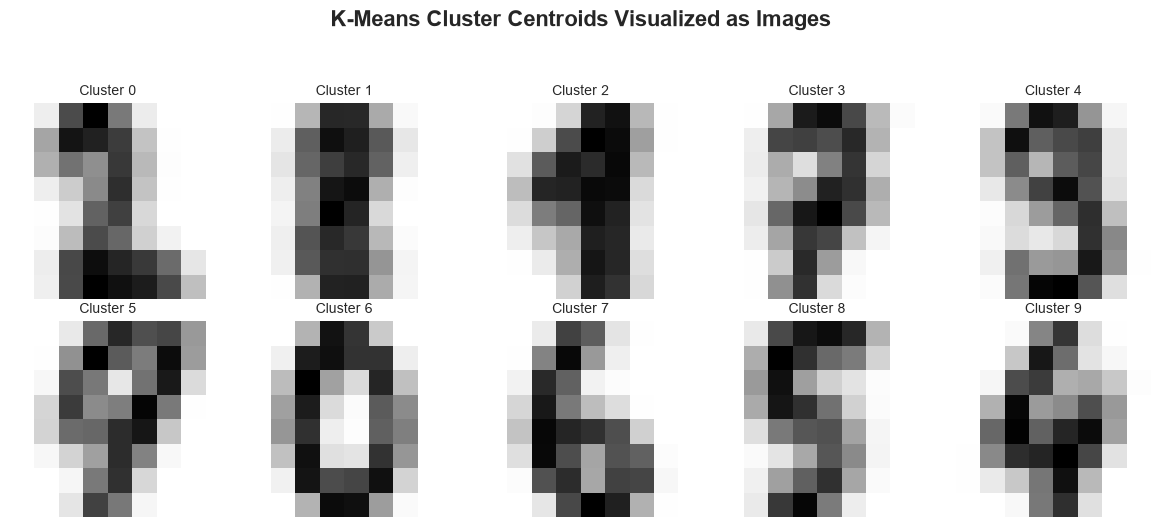

In [10]:
centroids_original_space = scaler.inverse_transform(kmeans_final.cluster_centers_)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(centroids_original_space[i].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"Cluster {i}", fontsize=10)
    ax.axis("off")
fig.suptitle("K-Means Cluster Centroids Visualized as Images", y=1.05, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 9: Compare Clusters with Actual Digit Labels

Cluster vs Actual Digit Comparison:

Actual Digit    0   1    2    3    4    5    6    7   8    9
Cluster                                                     
0               0  27  141    1    0    0    0    0   0    0
1               0  97   24    7    3    2    5    1  99    2
2               0  58    4    0    7    0    1    3  15   19
3               0   0    2    7    4    0    0  155   2    8
4               0   0    5  160    0   41    0    0  48  144
5               0   0    0    0    9    0    0   18   0    3
6             177   0    1    0    0    0    1    0   1    0
7               0   0    0    0    0    3  174    0   3    0
8               0   0    0    8    1  134    0    2   6    4
9               1   0    0    0  157    2    0    0   0    0


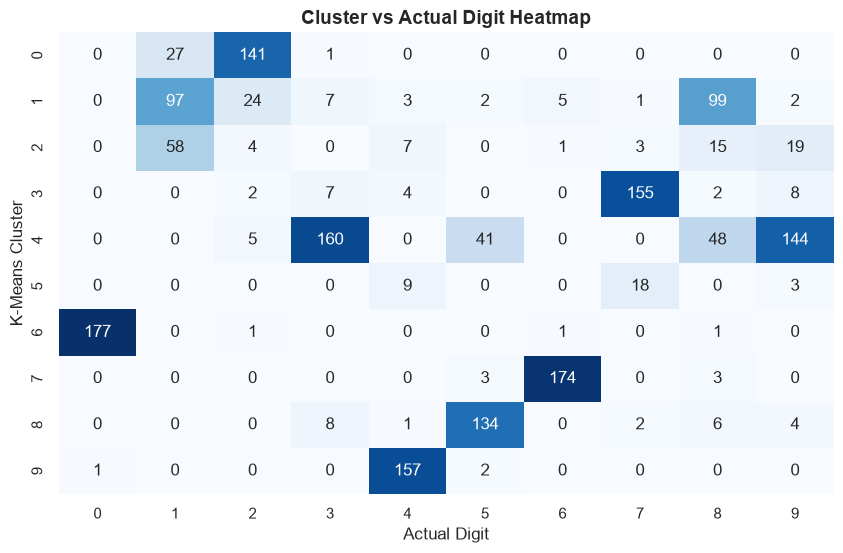

In [13]:
comparison = pd.crosstab(cluster_labels, y_true, rownames=["Cluster"], colnames=["Actual Digit"])
print("Cluster vs Actual Digit Comparison:\n")
print(comparison)

plt.figure(figsize=(10, 6))
sns.heatmap(comparison, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Cluster vs Actual Digit Heatmap", fontsize=14, fontweight='bold')
plt.ylabel("K-Means Cluster", fontsize=12), plt.xlabel("Actual Digit", fontsize=12)
plt.show()

### Step 10: Final Output

In [18]:
ari = adjusted_rand_score(y_true, cluster_labels)
nmi = normalized_mutual_info_score(y_true, cluster_labels)

print("Experiment Completed Successfully.")
print(f"\nOptimal Number of Clusters (K) selected   : {optimal_k}")
print(f"Final Silhouette Score                    : {silhouette_score(x_scaled, cluster_labels):.4f}")
print(f"Adjusted Rand Index                       : {ari:.4f}")
print(f"Normalized Mutual Information             : {nmi:.4f}")

Experiment Completed Successfully.

Optimal Number of Clusters (K) selected   : 10
Final Silhouette Score                    : 0.1501
Adjusted Rand Index                       : 0.5667
Normalized Mutual Information             : 0.6966


### Conclusion

- K-Means clustering was applied to the **Handwritten Digits dataset** (1,797 samples, 64 pixel-intensity features), a genuinely high-dimensional real-world dataset rather than a small 2-4 feature toy dataset.
- The **Elbow Method** showed a gradually decreasing WCSS curve without one sharp, obvious bend, reflecting the natural pixel-level overlap between visually similar digits.
- The **Silhouette Method** confirmed that cluster separability in raw pixel space is imperfect for several digit pairs, since digits like 3/8/9 or 4/9 share substantial stroke overlap.
- Choosing **K=10** (matching the known number of digit classes) still produced clusters that were **strongly aligned with the true digit labels**, as verified using the **Adjusted Rand Index** and **Normalized Mutual Information** against ground truth.
- Reconstructing each cluster centroid as an 8x8 image provided an intuitive, visual confirmation of what K-Means learned — most centroids resemble a recognizable "average" digit shape.

**Experiment Completed Successfully.**